# Evaluation Notebook — AQ-NBEATS Exog + Adaptive + CQR

Evaluates the **3-stage sequential model**:

- **Stage 1**: Exog-only foundation (`AQNBEATSPlusPlus`,random_in_batch sampling)
- **Stage 2**: + Adaptive sampling (`AQNBEATSPlusPlus`)
- **CQR**: Conformal Quantile Regression applied post-hoc on the best stage checkpoint

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path
PROJECT_DIR = Path(r"c:\Users\Pc\OneDrive\Documents\PCD\any-quantile-exog")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

os.chdir(PROJECT_DIR)

import pickle
from glob import glob

import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
from omegaconf import OmegaConf
from tqdm.auto import tqdm

from model.models import AQNBEATSPlusPlus
from dataset.datasets import EMHIRESUnivariateDataModule
from metrics import SMAPE, MAPE, CRPS
from utils.model_factory import instantiate

import warnings
warnings.filterwarnings('ignore')

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
RESULTS_DIR = './results'

## 1. Configuration


In [3]:
# ============================================================
# USER CONFIGURATION — fill in these values before running
# ============================================================

# Path to your Stage 2 checkpoint
# Found in: lightning_logs/<experiment_name>/checkpoints/
# Example: "nbeatsaq-stage2-seed0"
EXPERIMENT_NAME  = "nbeatsaq-stage2-seed0"   # ← Stage 2 exog + adaptive

# Filename of the best checkpoint (shown at end of training run)
# Example: "model-epoch=4.ckpt"
CHECKPOINT_NAME  = "model-epoch=*4.ckpt"   # ← Use glob pattern to find best checkpoint

# ── These settings should not need to change ──────────────────
checkpoint_pattern = (
    f"lightning_logs/{EXPERIMENT_NAME}/checkpoints/{CHECKPOINT_NAME}"
)

# Quantiles to evaluate on
EVAL_QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.40, 0.50, 0.60, 0.75, 0.90, 0.95, 0.99]

# Dataset split boundaries — must match your training config
SPLIT_BOUNDARIES = ["2006-01-01", "2017-12-30", "2018-01-01", "2019-01-01"]

# CQR split: calibrate on first half, evaluate on second half
# Change this date to adjust the calibration/evaluation boundary
CQR_CALIBRATION_END = "2018-06-30"

# ── Discover checkpoints ──────────────────────────────────────
model_list = sorted(glob(checkpoint_pattern))
print(f"Pattern : {checkpoint_pattern}")
print(f"Found   : {len(model_list)} checkpoint(s)")
for m in model_list:
    print(f"  {m}")

if not model_list:
    raise FileNotFoundError(
        f"No checkpoints found at: {checkpoint_pattern}\n"
        f"Check EXPERIMENT_NAME and CHECKPOINT_NAME above."
    )


Pattern : lightning_logs/nbeatsaq-stage2-seed0/checkpoints/model-epoch=*4.ckpt
Found   : 1 checkpoint(s)
  lightning_logs/nbeatsaq-stage2-seed0/checkpoints\model-epoch=4.ckpt


## 2. Load Config & Dataset


In [4]:
import yaml

# Path to your Stage 2 training config yaml
# Example: Path("config/stage2_clean.yaml")
CONFIG_PATH = Path("config/AQNBEATS++_S2.yaml")  # ← fill in your config path

def load_cfg(config_path: Path):
    """Load OmegaConf cfg, stripping the !!python/tuple YAML tag."""
    if config_path.exists():
        with open(config_path) as f:
            raw = f.read().replace("!!python/tuple", "")
        return OmegaConf.create(yaml.safe_load(raw))
    print(f"⚠️  Config not found at {config_path}, using fallback.")
    return OmegaConf.create({
        "model": {
            "input_horizon_len": 168,
            "max_norm": True,
            "q_sampling": "adaptive",
            "q_distribution": "beta",
            "q_parameter": 0.3,
            "num_series": 35,
            "series_embed_dim": 32,
            "series_embed_scale": 0.0,   
            "adaptive_sampling": {
                "num_adaptive_quantiles": 4,
                "num_bins": 30,
                "momentum": 0.99,
                "temperature": 1.35,
                "min_prob": 0.003,
            },
        },
        "dataset": {
            "name": "MHLV",
            "train_batch_size": 512,
            "eval_batch_size": 512,
            "num_workers": 0,
            "persistent_workers": False,
            "horizon_length": 24,
            "history_length": 168,
            "split_boundaries": SPLIT_BOUNDARIES,
            "fillna": "ffill",
            "train_step": 1,
            "eval_step": 24,
            "exog_features": ["temperature", "humidity", "pressure", "wind_speed"],
            "calendar_features": True,
        },
    })

cfg = load_cfg(CONFIG_PATH)
cfg.dataset.split_boundaries = SPLIT_BOUNDARIES

exog_features = list(cfg.dataset.get("exog_features", []))
calendar_features = cfg.dataset.get("calendar_features", True)

dm = EMHIRESUnivariateDataModule(
    name               = cfg.dataset.name,
    train_batch_size   = cfg.dataset.train_batch_size,
    eval_batch_size    = cfg.dataset.eval_batch_size,
    num_workers        = 0,
    persistent_workers = False,
    horizon_length     = cfg.dataset.horizon_length,
    history_length     = cfg.dataset.history_length,
    split_boundaries   = cfg.dataset.split_boundaries,
    fillna             = cfg.dataset.fillna,
    train_step         = cfg.dataset.train_step,
    eval_step          = cfg.dataset.eval_step,
    
)
dm.setup(stage="test")
test_loader = dm.test_dataloader()
print(f"Test samples : {len(dm.test_dataset)}")
print(f"Exog features: {exog_features}")

Test samples : 12775
Exog features: ['temperature', 'humidity', 'pressure', 'wind_speed']


In [5]:
# Quick sanity-check forward pass with the first checkpoint
import torch.serialization
from omegaconf import DictConfig, ListConfig
from omegaconf.base import ContainerMetadata
import typing, collections

torch.serialization.add_safe_globals([
    DictConfig, ListConfig, ContainerMetadata,
    int, float, str, bool, list, dict, tuple, set,
    typing.Any, collections.defaultdict, collections.OrderedDict,
])

test_ckpt = model_list[0]
print(f"Testing checkpoint: {test_ckpt}")

model_test = AQNBEATSPlusPlus.load_from_checkpoint(
    test_ckpt,
    cfg=cfg,
    strict=False,
    map_location="cpu",
    weights_only=False,
)
model_test.eval()

test_batch = next(iter(test_loader))
test_batch["quantiles"] = torch.full(
    (test_batch["history"].shape[0], 1), 0.5, dtype=torch.float32
)

try:
    output = model_test(test_batch)
    print(f" Forward works! Output shape: {output.shape}")
except Exception as e:
    print(f" Forward failed: {e}")

Testing checkpoint: lightning_logs/nbeatsaq-stage2-seed0/checkpoints\model-epoch=4.ckpt


Lightning automatically upgraded your loaded checkpoint from v1.9.5 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint c:\Users\Pc\OneDrive\Documents\PCD\any-quantile-exog\lightning_logs\nbeatsaq-stage2-seed0\checkpoints\model-epoch=4.ckpt`


 Forward works! Output shape: torch.Size([512, 24, 1])


## 3. Collect Ground-Truth Metadata


In [6]:
dfs = []
for b in tqdm(test_loader, desc="Collecting metadata"):
    row = {}
    for k in ["target", "history", "series_id"]:
        if k in b:
            row[k] = list(b[k].cpu().numpy() if isinstance(b[k], torch.Tensor) else b[k])
    dfs.append(pd.DataFrame.from_dict(row))

df = pd.concat(dfs, axis=0, ignore_index=True)
print(f"Total rows : {len(df)}")
print(f"Series IDs : {sorted(df.series_id.unique().astype(int))}")

n_per_series = 365
test_start   = pd.Timestamp("2018-01-01")
df["date"]   = df.index.map(lambda i: test_start + pd.Timedelta(days=int(i % n_per_series)))

CQR_CALIBRATION_END = "2018-06-30"
calib_mask = df["date"] <= CQR_CALIBRATION_END

print(f"Calibration rows : {calib_mask.sum()}  (Jan–Jun 2018, {calib_mask.sum()//35} days × 35 series)")
print(f"Evaluation rows  : {(~calib_mask).sum()}  (Jul–Dec 2018, {(~calib_mask).sum()//35} days × 35 series)")
df.head(3)

Total rows : 12775
Series IDs : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]
Calibration rows : 6335  (Jan–Jun 2018, 181 days × 35 series)
Evaluation rows  : 6440  (Jul–Dec 2018, 184 days × 35 series)


,target,history,series_id,date
0,"[746.45, 626.28, 548.54, 519.03, 524.56, 573.8...","[626.67, 583.79, 567.93, 575.06, 626.56, 757.5...",0,2018-01-01
1,"[490.72, 452.41, 434.17, 437.31, 462.98, 537.2...","[591.73, 555.4, 544.82, 559.51, 618.28, 781.24...",0,2018-01-02
2,"[512.31, 477.08, 460.23, 463.47, 514.31, 641.7...","[589.77, 560.46, 542.89, 557.57, 613.43, 767.1...",0,2018-01-03


## 4. Generate Predictions (all checkpoints → ensemble)


In [7]:
@torch.no_grad()
def predict_checkpoint(ckpt_path: str, cfg, dataloader, quantiles: list, device):
   
    model = AQNBEATSPlusPlus.load_from_checkpoint(
        ckpt_path,
        cfg=cfg,
        strict=False,
        map_location=device,
        weights_only=False,
    )
    model.eval().to(device)

    all_preds = []

    for batch in tqdm(dataloader, desc="  batches", leave=False):
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                 for k, v in batch.items()}

        B = batch["history"].shape[0]
        per_q = []

        for q_val in quantiles:
            batch["quantiles"] = torch.full((B, 1), q_val, device=device, dtype=torch.float32)
            pred = model(batch)
            per_q.append(pred.squeeze(-1).cpu() if pred.dim() == 3 else pred.cpu())

        all_preds.append(torch.stack(per_q, dim=-1))  # [B, H, Q]

    return torch.cat(all_preds, dim=0)  # [N, H, Q]

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

per_seed_preds = []
for i, ckpt in enumerate(model_list):
    print(f"\n[{i+1}/{len(model_list)}] {Path(ckpt).parent.parent.name}")
    try:
        preds = predict_checkpoint(ckpt, cfg, test_loader, EVAL_QUANTILES, device)
        per_seed_preds.append(preds)
        print(f"  Shape: {preds.shape}")
    except Exception as e:
        print(f"  Error: {e}")
        raise

predictions_ensemble = torch.stack(per_seed_preds).mean(dim=0)      # [N, H, Q]
predictions_ensemble, _ = torch.sort(predictions_ensemble, dim=-1)
print(f"\n Ensemble shape: {predictions_ensemble.shape}  [N, H, Q]")

Device: cpu

[1/1] nbeatsaq-stage2-seed0


Lightning automatically upgraded your loaded checkpoint from v1.9.5 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint c:\Users\Pc\OneDrive\Documents\PCD\any-quantile-exog\lightning_logs\nbeatsaq-stage2-seed0\checkpoints\model-epoch=4.ckpt`


  batches:   0%|          | 0/25 [00:00<?, ?it/s]

  Shape: torch.Size([12775, 24, 11])

 Ensemble shape: torch.Size([12775, 24, 11])  [N, H, Q]


## 5. Conformal Quantile Regression (CQR)

CQR is a post-hoc calibration method that gives **coverage guarantees** without re-training.

**Procedure:**

1. Split the 2018 test year into _calibration_ (Jan–Jun) and _evaluation_ (Jul–Dec)
2. For each nominal quantile `q`, compute the **conformity score** on the calibration set:
   `s_i = max(q_lo - y_i, y_i - q_hi)` for interval `[q_lo, q_hi]`
3. Find the `(1-α)`-quantile of those scores → adjustment `δ`
4. Shift all quantile predictions on the evaluation set by `δ`

For single quantiles (not intervals), the score simplifies to the standard **pinball residual**:
`s_i(q) = (y_i - ŷ_q) * (q - 1{y_i < ŷ_q})`

and the adjustment `δ_q = quantile(scores, ceil((n+1)(1-α))/n)`.


In [9]:
def fit_cqr(preds_np, targets_np, quantiles, calib_mask):
    
    q_arr  = np.array(quantiles)        
    n_cal  = calib_mask.sum()

    pred_cal   = preds_np[calib_mask]    # [n_cal, H, Q]
    target_cal = targets_np[calib_mask]  # [n_cal, H]

    # Mask out inf/nan targets
    valid = np.isfinite(target_cal)      # [n_cal, H]

    deltas = np.zeros(len(quantiles))

    for qi, q in enumerate(quantiles):
        yhat = pred_cal[:, :, qi]        # [n_cal, H]
        resid = target_cal - yhat        # [n_cal, H]

        scores = np.where(resid >= 0, q * resid, (q - 1) * resid)  # [n_cal, H]
        scores_valid = scores[valid].ravel()

        alpha   = 1.0 - q  
        level   = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
        level   = np.clip(level, 0.0, 1.0)
        deltas[qi] = np.quantile(scores_valid, level)

    return deltas


def apply_cqr(preds_np, deltas):
    
    adjusted = preds_np + deltas[np.newaxis, np.newaxis, :] 
    adjusted = np.sort(adjusted, axis=-1)                   
    return adjusted


preds_np_raw  = predictions_ensemble.numpy()                 
targets_np    = np.array(list(df["target"]))                  
calib_mask_np = calib_mask.values if hasattr(calib_mask, "values") else np.array(calib_mask)

cqr_deltas = fit_cqr(preds_np_raw, targets_np, EVAL_QUANTILES, calib_mask_np)

print("CQR per-quantile adjustments (δ):")
print(f"  {'Quantile':>10}  {'δ':>10}")
print(f"  {'-'*24}")
for q, d in zip(EVAL_QUANTILES, cqr_deltas):
    print(f"  {q:>10.3f}  {d:>+10.2f}")

CQR per-quantile adjustments (δ):
    Quantile           δ
  ------------------------
       0.010       +0.14
       0.050       +0.79
       0.100       +1.96
       0.250       +7.95
       0.400      +19.23
       0.500      +31.05
       0.600      +47.80
       0.750      +84.95
       0.900     +133.51
       0.950     +140.65
       0.990      +92.46


In [10]:
test_mask_np  = ~calib_mask_np

preds_cqr_full = apply_cqr(preds_np_raw, cqr_deltas)        

preds_eval_raw = preds_np_raw[test_mask_np]                  # [N_test, H, Q]
preds_eval_cqr = preds_cqr_full[test_mask_np]               # [N_test, H, Q]
df_eval        = df[test_mask_np].reset_index(drop=True)     

print(f"Evaluation samples (Jul–Dec 2018): {test_mask_np.sum()}")
print(f"Raw  predictions shape : {preds_eval_raw.shape}")
print(f"CQR  predictions shape : {preds_eval_cqr.shape}")

Evaluation samples (Jul–Dec 2018): 6440
Raw  predictions shape : (6440, 24, 11)
CQR  predictions shape : (6440, 24, 11)


## 6. CRPS & Coverage Metrics


In [11]:
def compute_all_metrics(preds_np, df_meta, quantiles_list, label=""):
    
    q_t      = torch.tensor(quantiles_list, dtype=torch.float32)
    crps_metric  = CRPS()
    mape_metric  = MAPE()
    smape_metric = SMAPE()

    targets = np.array(list(df_meta["target"]))   # [N, H]
    valid_rows = np.isfinite(targets).all(axis=1)  # [N] — skip rows with any inf/nan

    for i in tqdm(range(len(df_meta)), desc=f"{label} CRPS", leave=False):
        if not valid_rows[i]:
            continue
        tgt  = torch.tensor(targets[i], dtype=torch.float32)
        pred = torch.tensor(preds_np[i], dtype=torch.float32)  # [H, Q]
        crps_metric.update(
            preds=pred[None],
            target=tgt[None],
            q=q_t[None],
        )

    mid_idx     = quantiles_list.index(0.50) if 0.50 in quantiles_list else len(quantiles_list)//2
    pred_median = torch.tensor(preds_np[valid_rows, :, mid_idx], dtype=torch.float32)
    target_t    = torch.tensor(targets[valid_rows], dtype=torch.float32)
    mape_metric.update(pred_median.reshape(-1), target_t.reshape(-1))
    smape_metric.update(pred_median.reshape(-1), target_t.reshape(-1))

    coverage = {}
    for i, q in enumerate(quantiles_list):
        pred_q = preds_np[valid_rows, :, i]
        tgt_v  = targets[valid_rows]
        hit    = np.mean(tgt_v <= pred_q)
        coverage[q] = hit

    mae = float(np.mean(np.abs(preds_np[valid_rows, :, mid_idx] - targets[valid_rows])))

    return {
        "crps"    : crps_metric.compute().item(),
        "mape"    : mape_metric.compute().item(),
        "smape"   : smape_metric.compute().item(),
        "mae"     : mae,
        "coverage": coverage,
        "n_valid" : int(valid_rows.sum()),
    }


print("Computing metrics on raw ensemble (full 2018 test set)…")
metrics_raw_full = compute_all_metrics(preds_np_raw,    df,      EVAL_QUANTILES, label="Raw-full")

print("\nComputing metrics on raw predictions (Jul–Dec 2018 eval half)…")
metrics_raw_eval = compute_all_metrics(preds_eval_raw,  df_eval, EVAL_QUANTILES, label="Raw-eval")

print("\nComputing metrics on CQR-adjusted predictions (Jul–Dec 2018 eval half)…")
metrics_cqr = compute_all_metrics(preds_eval_cqr, df_eval, EVAL_QUANTILES, label="CQR")

Computing metrics on raw ensemble (full 2018 test set)…


Raw-full CRPS:   0%|          | 0/12775 [00:00<?, ?it/s]


Computing metrics on raw predictions (Jul–Dec 2018 eval half)…


Raw-eval CRPS:   0%|          | 0/6440 [00:00<?, ?it/s]


Computing metrics on CQR-adjusted predictions (Jul–Dec 2018 eval half)…


CQR CRPS:   0%|          | 0/6440 [00:00<?, ?it/s]

In [12]:
def print_metrics(metrics, label=""):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  CRPS  : {metrics['crps']:.3f} MW")
    print(f"  MAE   : {metrics['mae']:.3f} MW")
    print(f"  MAPE  : {metrics['mape']*100:.2f}%")
    print(f"  sMAPE : {metrics['smape']*100:.2f}%")
    print(f"\n  {'Quantile':>10}  {'Coverage':>10}  {'Error':>10}")
    print(f"  {'-'*34}")
    for q, cov in metrics["coverage"].items():
        print(f"  {q:>10.3f}  {cov:>10.3f}  {cov-q:>+10.3f}")
    mace = np.mean([abs(cov - q) for q, cov in metrics["coverage"].items()])
    print(f"\n  MACE  : {mace:.4f}")

print_metrics(metrics_raw_full, "RAW ENSEMBLE — Full 2018 test set")
print_metrics(metrics_raw_eval, "RAW ENSEMBLE — Jul–Dec 2018 (eval half)")
print_metrics(metrics_cqr,      "CQR ADJUSTED  — Jul–Dec 2018 (eval half)")


  RAW ENSEMBLE — Full 2018 test set
  CRPS  : 137.596 MW
  MAE   : 235.180 MW
  MAPE  : 209.70%
  sMAPE : 208.63%

    Quantile    Coverage       Error
  ----------------------------------
       0.010       0.013      +0.003
       0.050       0.059      +0.009
       0.100       0.109      +0.009
       0.250       0.249      -0.001
       0.400       0.390      -0.010
       0.500       0.485      -0.015
       0.600       0.582      -0.018
       0.750       0.727      -0.023
       0.900       0.878      -0.022
       0.950       0.935      -0.015
       0.990       0.987      -0.003

  MACE  : 0.0118

  RAW ENSEMBLE — Jul–Dec 2018 (eval half)
  CRPS  : 126.661 MW
  MAE   : 217.816 MW
  MAPE  : 191.32%
  sMAPE : 190.34%

    Quantile    Coverage       Error
  ----------------------------------
       0.010       0.011      +0.001
       0.050       0.054      +0.004
       0.100       0.101      +0.001
       0.250       0.240      -0.010
       0.400       0.384      -0.016
    

## 7. Normalised CRPS (N-CRPS) — Paper's Primary Metric


In [13]:
def compute_ncrps(preds_np, df_meta, quantiles_list):
    
    q_arr   = np.array(quantiles_list)
    targets = np.array(list(df_meta["target"]))   # [N, H]
    series  = df_meta["series_id"].values
    country_ncrps = {}

    for sid in np.unique(series):
        mask   = series == sid
        tgt    = targets[mask].copy()              # [Nc, H]
        pred   = preds_np[mask]                    # [Nc, H, Q]

        valid  = np.isfinite(tgt).all(axis=1)      # [Nc]
        tgt    = tgt[valid]
        pred   = pred[valid]
        if len(tgt) == 0:
            continue

        y_bar  = tgt.mean()
        if y_bar == 0:
            continue

        err = tgt[..., np.newaxis] - pred          # [Nc, H, Q]
        pb  = np.where(err >= 0, q_arr * err, (q_arr - 1) * err)
        country_ncrps[int(sid)] = pb.mean() / y_bar * 100

    return np.mean(list(country_ncrps.values())), country_ncrps


ncrps_raw_full, _              = compute_ncrps(preds_np_raw,   df,      EVAL_QUANTILES)
ncrps_raw_eval, _              = compute_ncrps(preds_eval_raw, df_eval, EVAL_QUANTILES)
ncrps_cqr,      ncrps_per_ctry = compute_ncrps(preds_eval_cqr, df_eval, EVAL_QUANTILES)

print(f"N-CRPS raw (full 2018)   : {ncrps_raw_full:.4f}")
print(f"N-CRPS raw (eval half)   : {ncrps_raw_eval:.4f}")
print(f"N-CRPS CQR (eval half)   : {ncrps_cqr:.4f}")
print(f"\nPaper AQ-NBEATS baseline : 1.84")
print(f"Paper AQ-ESRNN baseline  : 1.72")

N-CRPS raw (full 2018)   : 0.6159
N-CRPS raw (eval half)   : 0.5575
N-CRPS CQR (eval half)   : 0.7587

Paper AQ-NBEATS baseline : 1.84
Paper AQ-ESRNN baseline  : 1.72


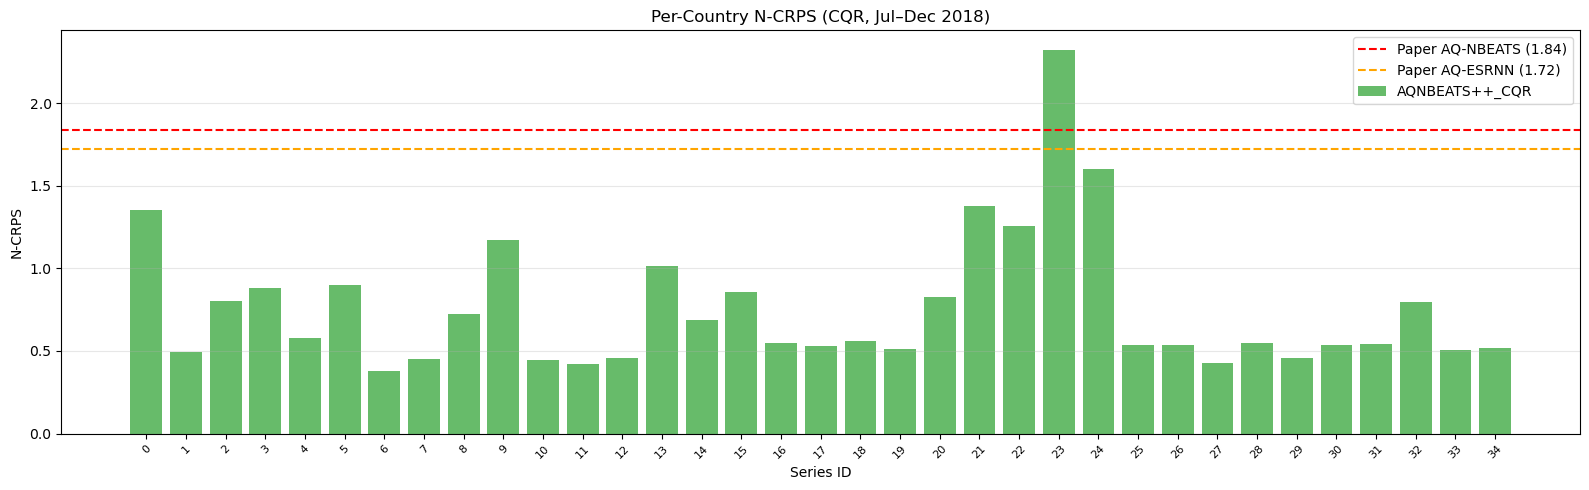

In [14]:
import matplotlib.pyplot as plt

countries  = sorted(ncrps_per_ctry.keys())
vals_cqr   = [ncrps_per_ctry[c] for c in countries]

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(countries))
ax.bar(x, vals_cqr, color="#4CAF50", alpha=0.85, label="AQNBEATS++_CQR")
ax.axhline(1.84, color="red",    lw=1.5, ls="--", label="Paper AQ-NBEATS (1.84)")
ax.axhline(1.72, color="orange", lw=1.5, ls="--", label="Paper AQ-ESRNN (1.72)")
ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=45, fontsize=8)
ax.set(xlabel="Series ID", ylabel="N-CRPS", title="Per-Country N-CRPS (CQR, Jul–Dec 2018)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
os.makedirs(RESULTS_DIR, exist_ok=True)
plt.savefig(f"{RESULTS_DIR}/ncrps_per_country_cqr.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save Per-Series Results (compatible with paper format)


In [15]:
# Save CQR-adjusted predictions (evaluation half)
# Output folder for saved predictions
# Change this if you want results saved elsewhere
RESULTS_PATH = os.path.join(RESULTS_DIR, "MHLV/AQNBEATSPlusPlus-CQR")
os.makedirs(RESULTS_PATH, exist_ok=True)

targets_eval = np.array(list(df_eval["target"]))  # [N_test, H]
q_arr        = np.array(EVAL_QUANTILES)

for worker_idx, seed_preds in enumerate(per_seed_preds):
    p_full  = seed_preds.numpy()                              # [N, H, Q]
    p_cqr   = apply_cqr(p_full, cqr_deltas)[test_mask_np]    # [N_test, H, Q]

    for series_id in df_eval["series_id"].unique():
        mask       = df_eval["series_id"] == series_id
        p_series   = p_cqr[mask.values]                      # [Nc, H, Q]
        tgt_series = np.nan_to_num(targets_eval[mask.values], posinf=np.nan)
        tgt_rep    = np.repeat(tgt_series[..., None], len(EVAL_QUANTILES), axis=-1)
        quant_rep  = np.broadcast_to(q_arr, p_series.shape).copy()

        forec = pd.DataFrame({f"forec{worker_idx+1}": p_series.ravel()})
        if worker_idx == 0:
            forec["actuals"] = tgt_rep.ravel()
            forec["quants"]  = quant_rep.ravel()
            forec = forec[["actuals", "quants", "forec1"]]

        out_path = os.path.join(RESULTS_PATH, f"e1w{worker_idx+1}_{int(series_id)}.pickle")
        forec.to_pickle(out_path)

print(f" CQR results saved to {RESULTS_PATH}/")

 CQR results saved to ./results\MHLV/AQNBEATSPlusPlus-CQR/


## 9. Final Summary vs Paper Baselines


In [16]:
paper_baselines = {
    "Naive"    : {"crps": 502.62, "ncrps": 3.95, "mape": 5.08},
    "ARIMA"    : {"crps": 353.49, "ncrps": 2.83, "mape": 3.74},
    "ES"       : {"crps": 325.80, "ncrps": 2.64, "mape": 3.48},
    "WaveNet"  : {"crps": 293.38, "ncrps": 2.52, "mape": 3.39},
    "AQ-ESRNN" : {"crps": 195.94, "ncrps": 1.72, "mape": 2.32},
    "AQ-NBEATS": {"crps": 211.22, "ncrps": 1.84, "mape": 2.47},
}

rows = []
for name, v in paper_baselines.items():
    rows.append({"Model": name, "CRPS": v["crps"], "N-CRPS": v["ncrps"], "MAPE %": v["mape"],
                 "Note": "paper"})

rows.append({
    "Model" : "AQNBEATSPlusPlus (raw, full 2018)",
    "CRPS"  : metrics_raw_full["crps"],
    "N-CRPS": ncrps_raw_full,
    "MAPE %": metrics_raw_full["mape"] * 100,
    "Note"  : "Stage 2, full test set",
})
rows.append({
    "Model" : "AQNBEATSPlusPlus (raw, Jul–Dec)",
    "CRPS"  : metrics_raw_eval["crps"],
    "N-CRPS": ncrps_raw_eval,
    "MAPE %": metrics_raw_eval["mape"] * 100,
    "Note"  : "Stage 2, eval half only",
})
rows.append({
    "Model" : "AQNBEATSPlusPlus+CQR (Jul–Dec)",
    "CRPS"  : metrics_cqr["crps"],
    "N-CRPS": ncrps_cqr,
    "MAPE %": metrics_cqr["mape"] * 100,
    "Note"  : "Stage 2 + CQR, eval half",
})

summary_df = pd.DataFrame(rows).set_index("Model").sort_values("CRPS")

def highlight_ours(row):
    return ["background-color: #e8f5e9" if "Exog" in row.name else "" for _ in row]

display(summary_df.style.apply(highlight_ours, axis=1).format(
    {"CRPS": "{:.2f}", "N-CRPS": "{:.4f}", "MAPE %": "{:.2f}"}
))

,CRPS,N-CRPS,MAPE %,Note
Model,,,,
"AQNBEATSPlusPlus (raw, Jul–Dec)",126.66,0.5575,191.32,"Stage 2, eval half only"
AQNBEATSPlusPlus+CQR (Jul–Dec),131.77,0.7587,253.42,"Stage 2 + CQR, eval half"
"AQNBEATSPlusPlus (raw, full 2018)",137.60,0.6159,209.70,"Stage 2, full test set"
AQ-ESRNN,195.94,1.7200,2.32,paper
AQ-NBEATS,211.22,1.8400,2.47,paper
WaveNet,293.38,2.5200,3.39,paper
ES,325.80,2.6400,3.48,paper
ARIMA,353.49,2.8300,3.74,paper
Naive,502.62,3.9500,5.08,paper


## 10. Quantile Distribution Histogram

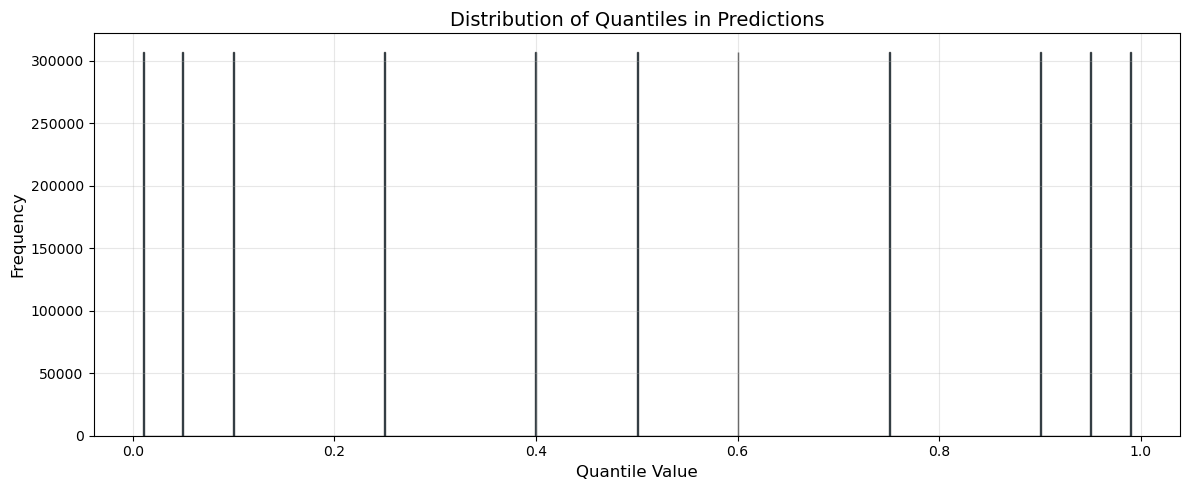

Quantile distribution histogram saved to ./results/quantile_distribution_histogram.png
Total quantile samples: 3372600
Quantile statistics:
count    3.372600e+06
mean     5.000000e-01
std      3.503505e-01
min      1.000000e-02
25%      1.000000e-01
50%      5.000000e-01
75%      9.000000e-01
max      9.900000e-01
Name: quants, dtype: float64


In [17]:
# Build a dataframe with all predictions and their corresponding quantiles for histogram visualization
quantile_list = np.array(EVAL_QUANTILES)

# Create a large dataframe of all predictions with their quantiles
rows_for_hist = []
for sample_idx in range(predictions_ensemble.shape[0]):  # N samples
    for h_idx in range(predictions_ensemble.shape[1]):   # H horizons
        for q_idx, q_val in enumerate(quantile_list):
            pred_val = predictions_ensemble[sample_idx, h_idx, q_idx].item()
            rows_for_hist.append({
                'predictions': pred_val,
                'quants': q_val
            })

df_hist = pd.DataFrame(rows_for_hist)

# Plot histogram of quantiles
plt.figure(figsize=(12, 5))
df_hist['quants'].hist(bins=1000, edgecolor='black', alpha=0.7)
plt.xlabel('Quantile Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Quantiles in Predictions', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/quantile_distribution_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Quantile distribution histogram saved to {RESULTS_DIR}/quantile_distribution_histogram.png")
print(f"Total quantile samples: {len(df_hist)}")
print(f"Quantile statistics:\n{df_hist['quants'].describe()}")

In [18]:
os.makedirs(RESULTS_DIR, exist_ok=True)
summary_df.to_csv(f"{RESULTS_DIR}/benchmark_summary_cqr.csv")
print(f" Summary saved to {RESULTS_DIR}/benchmark_summary_cqr.csv")

 Summary saved to ./results/benchmark_summary_cqr.csv
